<a href="https://colab.research.google.com/github/musab855/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — Which pages should a content team review first?

**Lane:** Refresh / Content Opportunity Scoring (chosen in ML-02, locked end of Week 4).
**Question:** given one month of search data and a review budget of a few dozen pages a week, which pages should an SEO/content editor open first, in what order, and why?
**Output:** a ranked review queue with reason codes and a per-row `wrong_if` — decision-support for a human, never an automated change.

This notebook is the single source of the deployed paper: every number on the public page is printed by a section below, and section 7 writes the machine-checkable copy to `work/outputs/capstone_metrics.json`.

**Skills loaded for this task:** `writing-research-papers` (structure) + `flyrank/flyrank-data` for the data.
**Claim vocabulary for every sentence below:** *observed, measured, directional, decision-support.* Nothing here is an experiment, so no sentence claims a causal effect or speaks for Google's ranking systems.
**Sections, in order:** 1) Question -> 2) Data -> 3) Methodology -> 4) Results vs baseline -> 5) Limitations -> 6) Ranked recommendations -> 7) Artifacts the paper embeds -> self-check.
**Inputs:** the March 2026 warehouse frame (cache-or-scan; the cache is gitignored, the HF token comes from Colab Secrets / env / `.env` and is never printed), the committed starter CSV (decay context only), and the receipts published in Weeks 4–7 (`work/outputs/*.json`).

In [1]:
# ---- Setup -----------------------------------------------------------------
# Runs from the repo root (Colab badge clone or local clone). The token is read
# from Colab Secrets (Weeks 4-7 stored it as HF_TOKEN2, then HF_TOKEN), the
# environment, or a local .env file, and is NEVER printed, stored, or written.
import os, sys, getpass, subprocess, importlib.util, shutil, json
from pathlib import Path

def find_repo_root(start):
    for p in [start, *start.parents]:
        if (p / "work").is_dir() and (p / "skills").is_dir():
            return p
    return None

root = find_repo_root(Path.cwd())
if root is None:
    if Path("/content").exists():
        dest = Path("/content/flyrank-ml-internship")   # Colab
    else:
        dest = Path.cwd() / "flyrank-ml-internship"     # local / other
    if (dest / "work").is_dir() and (dest / "skills").is_dir():
        print(f"repo folder already present - reusing it: {dest}")
        root = dest
    else:
        if dest.exists():
            shutil.rmtree(dest)          # leftover from an interrupted clone
        proc = subprocess.run(
            ["git", "clone", "--depth", "1",
             "https://github.com/musab855/flyrank-ml-internship.git", str(dest)],
            capture_output=True, text=True)
        if proc.returncode != 0:
            print(proc.stdout); print(proc.stderr)
            raise RuntimeError(f"git clone failed (exit {proc.returncode}) - "
                               "read git's message above, fix it, re-run this cell.")
        root = dest
os.chdir(root)

missing = [p for p in ("duckdb", "huggingface_hub") if importlib.util.find_spec(p) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)
    importlib.invalidate_caches()

def load_token():
    # Colab Secrets first, then the environment, then the local .env file.
    try:
        from google.colab import userdata
        for key in ("HF_TOKEN2", "HF_TOKEN"):
            try:
                token = userdata.get(key)
                if token:
                    return token
            except Exception:
                pass
    except Exception:
        pass
    token = os.environ.get("HF_TOKEN")
    if token:
        return token
    env_file = Path(".env")
    if env_file.exists():
        for line in env_file.read_text().splitlines():
            if line.strip().startswith("HF_TOKEN"):
                return line.split("=", 1)[1].strip().strip(chr(34) + chr(39))
    return getpass.getpass("Paste your Hugging Face READ token (hf_...): ")

print("working directory:", Path.cwd())

working directory: C:\Users\Asus\Downloads\flyrank-ml-internship


## 1. Question

*The decision this supports, written down before anything is trained.*

> For an SEO specialist or content strategist who can review only a few dozen pages a week, deciding which pages to prioritize, we build a ranked **priority score** from one month of observed search data, scored by **precision@K** against an outcome observed in a later window, under a **client-grouped** split. A wrong call costs about 30 minutes of reviewer time (a page that did not need work) or continued visibility loss on a page nobody opened (a page that did). A fixed rule is not enough because the transparent rule is strong at the very top of one list but runs out of signal deeper down — it cannot weigh several moderate signals together. We claim only **observed / directional / decision-support** results: this work orders human review, it does not cause anything and says nothing about how any search engine ranks pages.

In [2]:
# ---- The frame, and the metric named before any training -------------------
import numpy as np
import pandas as pd
from IPython.display import display

FRAME = {
    "lane": "Refresh / Content Opportunity Scoring",
    "decision": "which pages a reviewer opens first this week",
    "unit of analysis": "one content page (pseudonymous content_id), March 2026",
    "output": "ranked review queue + reason codes + per-row wrong_if",
    "label": "impressions days 16-31 < impressions days 1-15 (observed afterwards)",
    "metric": "precision@K (K = 10 / 20 / 50), read next to ROC-AUC and average precision",
    "cost of a wrong call": "~30 min of reviewer time (false positive) vs continued visibility loss (false negative)",
    "claim level": "observed / measured / directional / decision-support - never causal",
    "random_state": 42,
}
display(pd.Series(FRAME, dtype=object).to_frame("value"))

# The metric exists and runs TODAY, on a toy ranking - defined before any model.
def precision_at_k(labels, scores, k):
    order = np.argsort(-np.asarray(scores), kind="stable")[:k]
    return float(np.asarray(labels)[order].mean())

demo_y = np.array([1, 1, 1, 0, 0])
demo_s = np.array([0.9, 0.8, 0.7, 0.6, 0.5])   # already in descending order
assert precision_at_k(demo_y, demo_s, 3) == 1.0
assert abs(precision_at_k(demo_y, demo_s, 5) - 0.6) < 1e-12
print("precision@K defined and checked on a toy ranking before any training "
      "(K=3 -> 1.000, K=5 -> 0.600).")

,value
lane,Refresh / Content Opportunity Scoring
decision,which pages a reviewer opens first this week
unit of analysis,"one content page (pseudonymous content_id), Ma..."
output,ranked review queue + reason codes + per-row w...
label,impressions days 16-31 < impressions days 1-15...
metric,"precision@K (K = 10 / 20 / 50), read next to R..."
cost of a wrong call,~30 min of reviewer time (false positive) vs c...
claim level,observed / measured / directional / decision-s...
random_state,42


precision@K defined and checked on a toy ranking before any training (K=3 -> 1.000, K=5 -> 0.600).


## 2. Data

*Which release, which tables, which window, what I excluded and why — public-safe.*

- **Release:** `FlyRank/internship-warehouse` build v20260703 on Hugging Face (gated, data-use terms accepted).
- **Table used:** `fact_content_daily_performance` (78,835,655 rows at report_date x client x content grain) — this run reads the **March 2026 slice only** (`2026-03-01` .. `2026-03-31`), aggregating the daily rows up to one row per page.
- **Contract checked against** `dim_content` (519,606 content items) in ML-04: grain, counts, and the availability flags were verified before any feature was built.
- **Deliberately not used:** `fact_content_query_90d` (query-level rows — raw queries are never public, so they never enter this work), and any per-client identity beyond pseudonymous `client_hash_id`.
- **Also used:** the committed starter CSV (`data/raw/content_refresh_anonymized.csv`, 30,000 pages) for the age/freshness context in section 6 — a different dataset and a different label from the queue, never a queue input.
- **Exclusions, with counts printed below:** pages with no position data in the feature window (`position` NaN), pages where `position == 0` is the "no data" placeholder, and pages whose label is undefined because one half of the month has no GSC data. Undefined labels are **dropped, not guessed** — no page is labelled declining (or not) without both windows being measurable.
- **Panel care:** every row is filtered on `gsc_data_available = TRUE` before aggregating, so zero-filled days never masquerade as "no demand".
- **Public safety:** outputs here are aggregates, pseudonymous IDs, and charts. No client names, domains, URLs, titles, or queries exist anywhere in this notebook.

In [3]:
# ---- Data: same SQL, same window, same filters as Weeks 4-7 ----------------
# March 2026. Features = days 1-15; the label is observed on days 16-31.
# Cache first (gitignored, never committed); the heavy scan runs on a cache miss.
CACHE = Path("work/outputs/feature_frame_march_audit.csv")

if CACHE.exists():
    df = pd.read_csv(CACHE)
    print(f"Cache hit: {len(df):,} rows from {CACHE}")
else:
    HF_TOKEN = load_token()
    import duckdb
    con = duckdb.connect()
    con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{HF_TOKEN}')")
    rel = "hf://datasets/FlyRank/internship-warehouse"
    df = con.sql(f"""
    WITH daily_averages AS (
      SELECT content_hash_id, client_hash_id,
        AVG(CASE WHEN report_date < '2026-03-16' AND gsc_data_available THEN gsc_impressions ELSE NULL END) AS gsc_impressions_1to15,
        AVG(CASE WHEN report_date < '2026-03-16' AND gsc_data_available THEN gsc_clicks ELSE NULL END) AS gsc_clicks_1to15,
        AVG(CASE WHEN report_date < '2026-03-16' AND gsc_data_available THEN gsc_avg_position ELSE NULL END) AS position_1to15,
        AVG(CASE WHEN report_date >= '2026-03-16' AND gsc_data_available THEN gsc_impressions ELSE NULL END) AS gsc_impressions_16to31
      FROM read_parquet('{rel}/fact_content_daily_performance/**/*.parquet')
      WHERE report_date >= '2026-03-01' AND report_date < '2026-04-01' AND gsc_data_available = TRUE
      GROUP BY content_hash_id, client_hash_id
    )
    SELECT content_hash_id AS content_id, client_hash_id,
      gsc_impressions_1to15 AS gsc_impressions_avg,
      gsc_clicks_1to15 AS gsc_clicks_avg,
      position_1to15 AS position_avg,
      gsc_impressions_16to31,
      (CASE WHEN gsc_impressions_16to31 IS NULL OR gsc_impressions_1to15 IS NULL THEN NULL
            WHEN gsc_impressions_16to31 < gsc_impressions_1to15 THEN 1 ELSE 0 END) AS is_declining_label
    FROM daily_averages
    """).df()
    CACHE.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(CACHE, index=False)
    print(f"Scanned the warehouse (March 2026): {len(df):,} rows -> cached at {CACHE}")

# Exclusions: undefined label or no position data -> dropped, not guessed.
n_before = len(df)
pos_nan, pos_zero = df["position_avg"].isna(), df["position_avg"] == 0
lab_nan = df["is_declining_label"].isna()
n_pos_nan, n_pos_zero = int(pos_nan.sum()), int(pos_zero.sum())
n_lab_nan_extra = int((lab_nan & ~pos_nan & ~pos_zero).sum())

print(f"Rows before filter: {n_before:,}")
print(f"Excluding position NaN (no GSC data days 1-15): {n_pos_nan:,}")
print(f"Excluding position == 0 (the 'no data' placeholder): {n_pos_zero:,}")
print(f"Excluding undefined labels (no GSC data in one half): {n_lab_nan_extra:,}")

df = df[~pos_nan & ~pos_zero & ~lab_nan].copy()
df["is_declining_label"] = df["is_declining_label"].astype(int)
df = df.sort_values("content_id", kind="stable").reset_index(drop=True)   # canonical order
assert len(df) + n_pos_nan + n_pos_zero + n_lab_nan_extra == n_before

# The label's own window column exists in this cache only so ML-09 could prove
# the harness detects leakage. This notebook never uses it - drop it now.
df = df.drop(columns=["gsc_impressions_16to31"])

df["ctr"] = np.where(df["gsc_impressions_avg"] > 0,
                     df["gsc_clicks_avg"] / df["gsc_impressions_avg"], 0.0)
base_rate = df["is_declining_label"].mean()

# The universe must match Weeks 4-7 exactly, or nothing downstream is comparable.
assert len(df) == 140_599, f"expected 140,599 pages, got {len(df):,}"
assert abs(base_rate - 0.465) < 0.0005, f"base rate {base_rate:.3f}"

print(f"\nModeling frame: {len(df):,} pages, {df['client_hash_id'].nunique()} clients")
print(f"Base rate (share labelled declining): {base_rate:.3f}")
print(f"Visibility in frame: {df['gsc_impressions_avg'].sum():,.0f} impressions/day")

Cache hit: 176,738 rows from work\outputs\feature_frame_march_audit.csv
Rows before filter: 176,738
Excluding position NaN (no GSC data days 1-15): 24,757
Excluding position == 0 (the 'no data' placeholder): 1,306
Excluding undefined labels (no GSC data in one half): 10,076



Modeling frame: 140,599 pages, 43 clients
Base rate (share labelled declining): 0.465
Visibility in frame: 8,895,076 impressions/day


## 3. Methodology

*Assumptions, features, label, baseline, validation design, leakage checks.*

**Assumptions.** (1) A page's first half of March is knowable at the moment a reviewer is assigned work; (2) review capacity is scarce, so the output must be a *ranking*, not a classification; (3) impressions are exposure, not revenue — nothing in this data prices an outcome in currency.

**Features — three, all from days 1–15:** `gsc_impressions_avg`, `gsc_clicks_avg`, `position_avg`. Deliberately small: with one month and 43 clients, a wide feature list would be fitted noise. `content_id` / `client_hash_id` are used for grouping and folds only, never as inputs.

**Label (observed, later window):** `is_declining_label = 1` when a page's average daily impressions on days 16–31 were **lower** than on days 1–15. The label is an outcome that happens *after* the features, not a rule I wrote: base rate **0.465**.

**Baseline (transparent, built first):** `HIGH_VOLUME_POOR_POSITION` — flag pages with >= 500 impressions/day **and** average position >= 11, rank the flagged pages by impressions. The Week-4 signal audit (`w04_baseline_score.ipynb`) returned **CONFIRMED** on the impressions cutoff and **MIXED** on the position cutoff, so position >= 11 is kept as *policy* (a business assumption), not evidence — and this notebook inherits it unchanged. Two extra references make the comparison fair: `rule_full` (the same flag given the whole frame to rank) and `impressions_only` (impressions with no flag at all).

**Validation design:** client-grouped 5-fold out-of-fold scoring, `random_state = 42` — every client sits in exactly one test fold, so every page is scored by a model that never saw its client. Precision@K is computed on the pooled out-of-fold scores (one queue, not five). ML-09 ran the same harness under a row-random split for contrast and re-derived the published numbers from scratch.

**Leakage checks (asserted in code below):** no label-derived, trend, ID, or baseline column may appear in the feature list; the feature window strictly precedes the label window; and ML-09's deliberate confession showed what a real leak looks like (forest ROC-AUC 0.654 -> 0.997 when the label's own window was handed to the model) — after which the column was removed and the honest number kept.

In [4]:
# ---- Config: one seed, one feature list, the receipts I check against -------
%matplotlib inline
import sklearn
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

RANDOM_STATE = 42           # every random step in this notebook uses this one seed
N_FOLDS = 5
BASE_FEATURES = ["gsc_impressions_avg", "gsc_clicks_avg", "position_avg"]
IMPRESSIONS_THRESHOLD = 500  # ML-07 cutoff, unchanged
POSITION_THRESHOLD = 11      # ML-07 cutoff, unchanged (policy, verdict MIXED)
METRIC_ORDER = ["precision_at_10", "precision_at_20", "precision_at_50", "roc_auc", "avg_precision"]
REVIEW_MINUTES_PER_PAGE = 30 # reviewer-time assumption, written down, not measured
TIER_B_MIN_SCORE = 0.80      # forest OOF score needed to enter Tier B
TIER_B_MIN_IMPRESSIONS = 100 # ...and the visibility floor for it

# The baseline, defined here (its cutoffs live in this config cell): flag the
# visible-and-deep pages, rank flagged pages by impressions, everyone else 0.
flag = ((df["gsc_impressions_avg"] >= IMPRESSIONS_THRESHOLD) &
        (df["position_avg"] >= POSITION_THRESHOLD)).to_numpy()
df["rule_full"] = df["gsc_impressions_avg"] + 1e9 * flag     # reference rank, no training
df["impressions_only"] = df["gsc_impressions_avg"]
assert int(flag.sum()) == 1_074, f"expected 1,074 flagged pages, got {int(flag.sum()):,}"
print(f"Baseline HIGH_VOLUME_POOR_POSITION flags {int(flag.sum()):,} pages ({flag.mean():.2%}) "
      f"of {len(df):,}")

# The 25 numbers published in ML-08 and re-derived in ML-09 - checked below.
W05_PUBLISHED = {
    "rule":               {"precision_at_10": 1.000, "precision_at_20": 0.950, "precision_at_50": 0.880, "roc_auc": 0.505, "avg_precision": 0.469},
    "rule_full":          {"precision_at_10": 1.000, "precision_at_20": 0.950, "precision_at_50": 0.880, "roc_auc": 0.609, "avg_precision": 0.537},
    "impressions_only":   {"precision_at_10": 0.700, "precision_at_20": 0.700, "precision_at_50": 0.620, "roc_auc": 0.609, "avg_precision": 0.534},
    "logistic_regression": {"precision_at_10": 0.700, "precision_at_20": 0.700, "precision_at_50": 0.780, "roc_auc": 0.630, "avg_precision": 0.571},
    "random_forest":      {"precision_at_10": 0.500, "precision_at_20": 0.550, "precision_at_50": 0.660, "roc_auc": 0.654, "avg_precision": 0.583},
}

print(f"numpy {np.__version__} | pandas {pd.__version__} | scikit-learn {sklearn.__version__} | "
      f"matplotlib {plt.matplotlib.__version__}")
print(f"random_state = {RANDOM_STATE} (fixed, so a rerun reproduces every table below)")
print("features:", BASE_FEATURES)
print(f"queue policies: Tier B score >= {TIER_B_MIN_SCORE}, Tier B impressions >= "
      f"{TIER_B_MIN_IMPRESSIONS}, review time assumption {REVIEW_MINUTES_PER_PAGE} min/page")

# ---- Leakage checks on the final feature set (ML-04, ML-09) ----------------
BANNED_FEATURES = {
    "content_id", "client_hash_id",             # IDs: grouping only, never features
    "is_declining_label", "ctr",                # the label itself, and a same-window ratio
    "trend_pct", "trend_direction",             # the label's ancestors (the Week-3 trap)
    "gsc_impressions_16to31",                   # the label's own window
    "rule_full", "impressions_only",            # baseline scores, not inputs
}
violations = set(BASE_FEATURES) & BANNED_FEATURES
assert not violations, f"banned columns in the feature list: {violations}"
print("\nbanned from ever being a feature:", sorted(BANNED_FEATURES))
print("violations:", violations or "none")

timeline = pd.DataFrame([
    {"stage": "features", "window": "2026-03-01 .. 2026-03-15",
     "knowable at the decision moment?": "yes - strictly before it"},
    {"stage": "prediction", "window": "2026-03-16",
     "knowable at the decision moment?": "this IS the moment"},
    {"stage": "label", "window": "2026-03-16 .. 2026-03-31",
     "knowable at the decision moment?": "no - strictly after"},
])
print("\nTimeline (drawn, not assumed):")
display(timeline)

# ---- Split: client-grouped 5-fold, no client on both sides -----------------
def make_grouped_folds(frame, n_splits=N_FOLDS, seed=RANDOM_STATE):
    sizes = frame.groupby("client_hash_id").size()
    order = list(sizes.index)
    np.random.default_rng(seed).shuffle(order)      # shuffle so ties are not alphabetical
    fold_of_client, load = {}, [0] * n_splits
    for client in order:
        i = int(np.argmin(load))                    # always fill the lightest fold
        fold_of_client[client] = i
        load[i] += int(sizes[client])
    return frame["client_hash_id"].map(fold_of_client).astype(int)

df["fold_grouped"] = make_grouped_folds(df)
assert df.groupby("client_hash_id")["fold_grouped"].nunique().eq(1).all(), "a client spans two folds"
for f in range(N_FOLDS):
    part = df[df["fold_grouped"] == f]
    assert part["is_declining_label"].nunique() == 2, f"fold {f} has one class only"
assert int((df["fold_grouped"] >= 0).sum()) == len(df), "a page is missing a fold"
print("\nCheck: client-disjoint folds, both classes present, every page in exactly one test fold.")

Baseline HIGH_VOLUME_POOR_POSITION flags 1,074 pages (0.76%) of 140,599
numpy 1.26.4 | pandas 2.1.1 | scikit-learn 1.3.1 | matplotlib 3.8.0
random_state = 42 (fixed, so a rerun reproduces every table below)
features: ['gsc_impressions_avg', 'gsc_clicks_avg', 'position_avg']
queue policies: Tier B score >= 0.8, Tier B impressions >= 100, review time assumption 30 min/page

banned from ever being a feature: ['client_hash_id', 'content_id', 'ctr', 'gsc_impressions_16to31', 'impressions_only', 'is_declining_label', 'rule_full', 'trend_direction', 'trend_pct']
violations: none

Timeline (drawn, not assumed):


,stage,window,knowable at the decision moment?
0,features,2026-03-01 .. 2026-03-15,yes - strictly before it
1,prediction,2026-03-16,this IS the moment
2,label,2026-03-16 .. 2026-03-31,no - strictly after



Check: client-disjoint folds, both classes present, every page in exactly one test fold.


In [5]:
# ---- Baseline + out-of-fold training: 5 client folds x 2 models ------------
def rule_score(frame):
    f = (frame["gsc_impressions_avg"] >= IMPRESSIONS_THRESHOLD) & \
        (frame["position_avg"] >= POSITION_THRESHOLD)
    return np.where(f, frame["gsc_impressions_avg"], 0.0)

def metric_bundle(labels, scores):
    return {"precision_at_10": precision_at_k(labels, scores, 10),
            "precision_at_20": precision_at_k(labels, scores, 20),
            "precision_at_50": precision_at_k(labels, scores, 50),
            "roc_auc": roc_auc_score(labels, scores),
            "avg_precision": average_precision_score(labels, scores)}

def build_models():
    return {"logistic_regression": Pipeline([
                ("log", ColumnTransformer([("log", FunctionTransformer(np.log1p), [0, 1])],
                                          remainder="passthrough")),
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(class_weight="balanced", max_iter=1000,
                                             random_state=RANDOM_STATE))]),
            "random_forest": RandomForestClassifier(
                n_estimators=200, max_depth=10, min_samples_leaf=25,
                class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE)}

y = df["is_declining_label"].to_numpy()
X = df[BASE_FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0)
scores = {"rule": rule_score(df),
          "rule_full": df["rule_full"].to_numpy(),
          "impressions_only": df["impressions_only"].to_numpy(),
          "logistic_regression": np.zeros(len(df)),
          "random_forest": np.zeros(len(df))}

for f in range(N_FOLDS):
    test = (df["fold_grouped"] == f).to_numpy()
    train = ~test
    models = build_models()
    for name in ("logistic_regression", "random_forest"):
        models[name].fit(X.iloc[train], y[train])
        scores[name][test] = models[name].predict_proba(X.iloc[test])[:, 1]
    print(f"fold {f}: {int(test.sum()):,} pages scored out-of-fold")

for name, s in scores.items():
    df[f"oof__{name}"] = s
pooled = {name: metric_bundle(y, s) for name, s in scores.items()}

# ---- Receipt 1: the 25 numbers published in ML-08 / re-derived in ML-09 ----
rows = []
for method, wanted in W05_PUBLISHED.items():
    for metric, target in wanted.items():
        got = pooled[method][metric]
        rows.append({"method": method, "metric": metric, "published": target,
                     "this_run": round(got, 3),
                     "check": "MATCH" if abs(got - target) <= 0.005 else "DIFF"})
receipts = pd.DataFrame(rows)
display(receipts.pivot(index="method", columns="metric",
                       values="this_run").loc[:, METRIC_ORDER].round(3))
worst = float((receipts["this_run"] - receipts["published"]).abs().max())
print(f"receipts: {(receipts['check'] == 'MATCH').sum()}/{len(receipts)} MATCH at +-0.005 "
      f"(worst gap this run: {worst:.4f})")
assert (receipts["check"] == "MATCH").all(), "a published number did not reproduce - stop and investigate"

# ---- Receipt 2: the receipts file written by ML-10 -------------------------
pb = json.loads(Path("work/outputs/playbook_metrics.json").read_text(encoding="utf-8"))
assert pb["frame"]["pages"] == len(df), "page count differs from the ML-10 receipts"
assert pb["frame"]["flagged_by_rule"] == int(flag.sum()), "flagged count differs"
assert abs(pb["frame"]["base_rate"] - base_rate) < 0.0005, "base rate differs"
for method, want in pb["receipts"].items():
    for metric, target in want.items():
        assert abs(pooled[method][metric] - target) <= 0.005, \
            f"{method}.{metric}: {pooled[method][metric]:.4f} vs receipts {target}"
print(f"all {sum(len(v) for v in pb['receipts'].values())} receipts in "
      f"work/outputs/playbook_metrics.json reproduced within 0.005")

fold 0: 32,790 pages scored out-of-fold


fold 1: 25,826 pages scored out-of-fold


fold 2: 26,662 pages scored out-of-fold


fold 3: 32,230 pages scored out-of-fold


fold 4: 23,091 pages scored out-of-fold


metric,precision_at_10,precision_at_20,precision_at_50,roc_auc,avg_precision
method,,,,,
impressions_only,0.7,0.70,0.62,0.609,0.534
logistic_regression,0.7,0.70,0.78,0.630,0.571
random_forest,0.5,0.55,0.66,0.654,0.583
rule,1.0,0.95,0.88,0.505,0.469
rule_full,1.0,0.95,0.88,0.609,0.537


receipts: 25/25 MATCH at +-0.005 (worst gap this run: 0.0000)
all 25 receipts in work/outputs/playbook_metrics.json reproduced within 0.005


## 4. Results (vs baseline)

*Model and baseline on the same pages, same split, same run — base rate printed beside them.*

The table above is one pooled out-of-fold pass over **140,599 pages** (base rate **0.465**), so every row is comparable and every learned row comes from models that never saw the client they scored. What the numbers say, in the order a reader needs them:

- **At the very top of the queue the transparent rule wins.** `HIGH_VOLUME_POOR_POSITION` ranked by impressions reads **P@50 0.880** (P@10 1.000, P@20 0.950) — about **1.9x** the base rate. That is the number a reviewer feels, because a reviewer only ever opens the top of the list.
- **Over the whole list the forest wins, modestly.** Client-grouped ROC-AUC **0.654 (forest) vs 0.609 (`rule_full`)** and average precision 0.583 vs 0.537 — a measured lead of **+0.045**, not the flattering +0.149 a tie-flawed rule AUC would suggest.
- **The unaided rule is a filter, not a ranker:** `rule` alone scores ROC-AUC **0.505** against the 0.500 no-skill line — its flagged pages are excellent, its rest-of-the-frame ordering is not information.
- **Logistic regression sits in between** (ROC-AUC 0.630, P@50 0.780): with three features and this little data, a linear model buys interpretability at a small cost in ranking quality.
- **Why ML beats a fixed rule here:** the rule is silent below its thresholds by construction (1,074 flagged pages, 0.8% of the frame), while the forest keeps ranking the other 139,525 — that is exactly where Tier B (section 6) comes from.

The validation contrast lives in ML-09: under a row-random split the forest read P@50 0.800 and the split put **100%** of test pages' clients into training; under the grouped split it reads **0.660** and the overlap is **0**. The honest number is the one above, and the top-50 queue itself changes with the split (5 of 50 pages shared).

In [6]:
# ---- The paper's results table + the reason codes behind every row ---------
tbl = pd.DataFrame(pooled).T.loc[:, METRIC_ORDER].round(3)
display(tbl)
rule_p50 = pooled["rule"]["precision_at_50"]
forest_auc = pooled["random_forest"]["roc_auc"]
print(f"base rate {base_rate:.3f} | pages {len(df):,} | clients {df['client_hash_id'].nunique()} | "
      f"split client-grouped {N_FOLDS}-fold OOF | seed {RANDOM_STATE}")
print(f"P@50: rule {rule_p50:.3f} vs base {base_rate:.3f} = {rule_p50 / base_rate:.2f}x "
      f"| forest P@50 {pooled['random_forest']['precision_at_50']:.3f}")
print(f"whole list ROC-AUC: rule {pooled['rule']['roc_auc']:.3f} | rule_full "
      f"{pooled['rule_full']['roc_auc']:.3f} | impressions_only {pooled['impressions_only']['roc_auc']:.3f} "
      f"| logistic {pooled['logistic_regression']['roc_auc']:.3f} | forest {forest_auc:.3f}")
print(f"forest - rule_full = {forest_auc - pooled['rule_full']['roc_auc']:+.3f} "
      f"(the measured whole-list gap the paper quotes)")

# Reason codes: computed from feature-window observables ONLY (days 1-15).
# The label is never an input; no product flag or score enters the queue.
impr, pos, ctr = df["gsc_impressions_avg"], df["position_avg"], df["ctr"]
rf = df["oof__random_forest"]

df["rc_high_volume_poor_position"] = (impr >= IMPRESSIONS_THRESHOLD) & (pos >= POSITION_THRESHOLD)
df["rc_near_zero_ctr"] = (ctr < 0.001) & (impr >= IMPRESSIONS_THRESHOLD)
df["rc_borderline"] = (((impr >= 450) & (impr < 550)) |
                       ((impr >= 450) & (pos >= 9.9) & (pos <= 12.1)))
df["rc_model_high_decline_rank"] = rf >= 0.65
df["rc_page_one_high_stakes"] = (impr >= IMPRESSIONS_THRESHOLD) & (pos < POSITION_THRESHOLD)
df["rc_low_volume_watch"] = impr < IMPRESSIONS_THRESHOLD

CODE_COLS = [c for c in df.columns if c.startswith("rc_")]
CODE_LABEL = {"rc_high_volume_poor_position": "HIGH_VOLUME_POOR_POSITION",
              "rc_near_zero_ctr": "NEAR_ZERO_CTR_IMPRESSIONS",
              "rc_borderline": "BORDERLINE_THRESHOLD",
              "rc_model_high_decline_rank": "MODEL_HIGH_DECLINE_RANK",
              "rc_page_one_high_stakes": "PAGE_ONE_HIGH_STAKES",
              "rc_low_volume_watch": "LOW_VOLUME_WATCH"}
assert set(CODE_LABEL) == set(CODE_COLS), "reason-code names and columns disagree"

counts = df[CODE_COLS].sum().astype(int)
assert (counts > 0).all(), "a reason code never fired - check its threshold"
base_cover = impr >= IMPRESSIONS_THRESHOLD
assert df.loc[base_cover, ["rc_high_volume_poor_position", "rc_page_one_high_stakes"]].sum(axis=1).eq(1).all()
assert df.loc[~base_cover, "rc_low_volume_watch"].all()
print("\ncoverage: every visible page has exactly one volume/position code; "
      "every below-floor page has LOW_VOLUME_WATCH")

code_table = pd.DataFrame({
    "fires_on_frame": counts.values,
    "share_of_frame": (counts / len(df)).map("{:.1%}".format).values,
    "fires_in_tier_A": df.loc[flag, CODE_COLS].sum().astype(int).values,
}, index=[CODE_LABEL[c] for c in CODE_COLS])
display(code_table.sort_values("fires_in_tier_A", ascending=False))
print(f"pages with >= 2 codes: {(df[CODE_COLS].sum(axis=1) >= 2).sum():,} "
      f"({(df[CODE_COLS].sum(axis=1) >= 2).mean():.1%}) - codes overlap on purpose")

df["reason_codes"] = df[CODE_COLS].apply(
    lambda r: "|".join(CODE_LABEL[c] for c in CODE_COLS if r[c]), axis=1)

,precision_at_10,precision_at_20,precision_at_50,roc_auc,avg_precision
rule,1.0,0.95,0.88,0.505,0.469
rule_full,1.0,0.95,0.88,0.609,0.537
impressions_only,0.7,0.70,0.62,0.609,0.534
logistic_regression,0.7,0.70,0.78,0.630,0.571
random_forest,0.5,0.55,0.66,0.654,0.583


base rate 0.465 | pages 140,599 | clients 43 | split client-grouped 5-fold OOF | seed 42
P@50: rule 0.880 vs base 0.465 = 1.89x | forest P@50 0.660
whole list ROC-AUC: rule 0.505 | rule_full 0.609 | impressions_only 0.609 | logistic 0.630 | forest 0.654
forest - rule_full = +0.045 (the measured whole-list gap the paper quotes)

coverage: every visible page has exactly one volume/position code; every below-floor page has LOW_VOLUME_WATCH


,fires_on_frame,share_of_frame,fires_in_tier_A
HIGH_VOLUME_POOR_POSITION,1074,0.8%,1074
MODEL_HIGH_DECLINE_RANK,6683,4.8%,621
NEAR_ZERO_CTR_IMPRESSIONS,940,0.7%,572
BORDERLINE_THRESHOLD,1044,0.7%,170
PAGE_ONE_HIGH_STAKES,2031,1.4%,0
LOW_VOLUME_WATCH,137494,97.8%,0


pages with >= 2 codes: 7,853 (5.6%) - codes overlap on purpose


## 5. Limitations

*What this work cannot claim — written before a reader asks.*

1. **One month, one portfolio, pseudonymized.** March 2026, 43 clients. Nothing here is measured on another month or another portfolio; generalization is untested.
2. **The label is a proxy.** "Impressions fell in days 16–31" is not "the page is bad": regression to the mean may sit inside every high-volume pick (a plausible mechanism, *not measured here*), and a page can hold steady and still be worthless.
3. **The position cutoff is policy, not evidence.** The Week-4 audit's verdict on `position >= 11` was MIXED (decline rate 47.2% -> 48.0% -> 45.9% -> 42.5% — non-monotonic). It is kept because it encodes a business assumption.
4. **Half of the flagged pages may not be human traffic.** CTR under 0.001 with >= 500 impressions/day: this data cannot separate bots from real demand, which is why verification precedes any editing.
5. **Not causal, not about any search engine's ranking systems.** No sentence here says a refresh recovers a page or that any algorithm "rewards" something. This ranks review candidates.
6. **Client-concentrated by construction.** One client owns most of the flagged pages, so any per-client reading of the queue inherits that skew — read within-client first.
7. **Scores are ranks, not probabilities.** The forest's out-of-fold score orders pages; "0.80" does not mean "80% chance of declining".

The monitoring table below is the receipts file's live trigger list: three triggers are already firing **by design** (they are visible weaknesses, not hidden ones), and the rest get their first real reading when a second month exists.

In [7]:
# ---- Limitation facts, re-measured live and cross-checked with receipts ----
near_zero_flagged = int(df.loc[flag, "rc_near_zero_ctr"].sum())
largest_client_share = df.loc[flag, "client_hash_id"].value_counts(normalize=True).iloc[0]

facts = {
    "window": "2026-03-01 .. 2026-03-31 (features days 1-15, label days 16-31)",
    "pages / clients": f"{len(df):,} / {df['client_hash_id'].nunique()}",
    "base rate (label)": round(base_rate, 3),
    "near-zero CTR among flagged": f"{near_zero_flagged:,} of {int(flag.sum()):,} "
                                   f"({near_zero_flagged / int(flag.sum()):.1%})",
    "largest client share of flagged": f"{largest_client_share:.1%}",
    "position cutoff verdict (Week 4)": "MIXED - policy, not evidence",
    "impressions cutoff verdict (Week 4)": "CONFIRMED",
    "row-random -> grouped P@50 (forest, ML-09)": "0.800 -> 0.660",
    "leak confession (ML-09)": "forest ROC-AUC 0.654 -> 0.997 when the label window was added, then removed",
}
display(pd.Series(facts, dtype=object).to_frame("value"))

# Live values must agree with the receipts file, or the prose above is stale.
assert near_zero_flagged == 572, near_zero_flagged
assert pb["queue"]["reason_codes_in_tier_a"]["NEAR_ZERO_CTR_IMPRESSIONS"] == near_zero_flagged
assert abs(largest_client_share - 0.747) < 0.005, f"{largest_client_share:.3f} vs 0.747 published"

triggers = pd.DataFrame(pb["triggers"])
display(triggers[["trigger", "rule", "current", "status"]])
firing = int((triggers["status"].str.startswith("FIRING")).sum())
print(f"{firing} triggers FIRING (all three are disclosed weaknesses), "
      f"{int((triggers['status'].str.startswith('CHECK')).sum())} waiting on a second month")

,value
window,"2026-03-01 .. 2026-03-31 (features days 1-15, ..."
pages / clients,"140,599 / 43"
base rate (label),0.465
near-zero CTR among flagged,"572 of 1,074 (53.3%)"
largest client share of flagged,74.7%
position cutoff verdict (Week 4),"MIXED - policy, not evidence"
impressions cutoff verdict (Week 4),CONFIRMED
"row-random -> grouped P@50 (forest, ML-09)",0.800 -> 0.660
leak confession (ML-09),forest ROC-AUC 0.654 -> 0.997 when the label w...


,trigger,rule,current,status
0,queue_precision@50 on new labels,"re-audit thresholds, then retrain, if P@50 < 0...",0.880 (March reference),BASELINE (same frame; real test is next month)
1,grouped ROC-AUC (forest),retrain + re-check features if AUC < 0.60 on a...,0.654 (March reference),BASELINE (same frame; real test is next month)
2,base-rate drift,if |new base rate - 0.465| > 0.05: check seaso...,0.465 (delta 0.000; drift undefined until a se...,BASELINE
3,near-zero-CTR share of top 50,if > 60%: traffic verification is mandatory be...,66% (33/50),FIRING (by design - verification gate stays on)
4,single-client share of top 50,if > 60%: warn the reviewer that the queue is ...,82%,"FIRING (warn reviewer, queue stays as-is)"
5,frame freshness,score the most recent complete month; if the f...,2026-03 scored in a later month (fixed evaluat...,FIRING (by design: the audit window is fixed; ...
6,queue overlap month over month,if < 50% of last month's top-50 returns: re-ra...,first run - no prior queue,CHECK AT NEXT RUN
7,feature drift (median impressions/day),if the frame median shifts > 20% vs the prior ...,first run - no prior frame,CHECK AT NEXT RUN
8,position cutoff verdict,Week-4 verdict was MIXED; if it flips on new d...,MIXED (Week 4),MONITOR


3 triggers FIRING (all three are disclosed weaknesses), 2 waiting on a second month


## 6. Ranked recommendations

*The action playbook: what a reviewer does with the numbers above.*

The queue is **tiered** because the two findings in section 4 point different ways:

- **Tier A — the rule's flagged pages, impressions order** (the measured P@50 0.880 order). These are pages with real visibility sitting off page one.
- **Tier B — the forest's extreme tail on visible pages the rule does not flag** (score >= 0.80, impressions >= 100). This is where ML beats the fixed rule: the rule is silent there by construction.

Each row carries **reason codes** (the one-line why, computed from days 1–15 only), an **action**, a **confidence** (`low` = borderline or near-zero CTR — the two ways this data misleads a reviewer; a Tier B row is never `high`, because a rank from one month is not a high-confidence claim), and a **`wrong_if`** string saying what would make the call wrong. Archetypes (rule-based tags on impressions/position, not clusters) give every *non*-queued page a standing action, so the inventory outside the queue is not unhandled.

In [8]:
# ---- Archetypes, tiers, actions, confidence - the ranked queue -------------
df["archetype"] = np.select(
    [df["rc_high_volume_poor_position"], df["rc_page_one_high_stakes"], impr >= 100],
    ["high_volume_deep_position", "page_one_high_stakes", "mid_volume_opportunity"],
    default="low_volume_long_tail")

STANDING_ACTION = {"high_volume_deep_position": "review_first_refresh_and_ctr",
                   "page_one_high_stakes": "protect_and_monitor",
                   "mid_volume_opportunity": "monitor",
                   "low_volume_long_tail": "monitor_only"}
df["standing_action"] = df["archetype"].map(STANDING_ACTION)

arch_tbl = df.groupby("archetype").agg(
    pages=("content_id", "count"),
    decline_rate=("is_declining_label", "mean"),
    median_impressions=("gsc_impressions_avg", "median"),
    median_position=("position_avg", "median")).round(3)
arch_tbl["share_of_frame"] = (arch_tbl["pages"] / len(df)).map("{:.2%}".format)
display(arch_tbl.loc[["high_volume_deep_position", "page_one_high_stakes",
                      "mid_volume_opportunity", "low_volume_long_tail"]])

tier_a = df[flag].sort_values(["gsc_impressions_avg", "content_id"],
                              ascending=[False, True]).copy()
tier_a["tier"] = "A"
tier_b_mask = (~flag) & (impr >= TIER_B_MIN_IMPRESSIONS) & (rf >= TIER_B_MIN_SCORE)
tier_b = df[tier_b_mask].sort_values(["oof__random_forest", "content_id"],
                                     ascending=[False, True]).copy()
tier_b["tier"] = "B"
queue = pd.concat([tier_a, tier_b], ignore_index=True)
queue["rank"] = np.arange(1, len(queue) + 1)

def action_for(row):
    if row["tier"] == "A":
        return "verify_traffic_first" if row["rc_near_zero_ctr"] else "review_first_refresh_and_ctr"
    if row["tier"] == "B":
        return "secondary_review"
    return STANDING_ACTION[row["archetype"]]

def confidence_for(row):
    if row["rc_borderline"] or row["rc_near_zero_ctr"]:
        return "low"
    if row["tier"] == "B":
        return "medium"                      # a rank is never high confidence
    if row["gsc_impressions_avg"] >= 2000 and row["position_avg"] >= 20:
        return "high"
    return "medium"

def wrong_if(row):
    if row["rc_near_zero_ctr"]:
        return (f"CTR under 0.001 on {row['gsc_impressions_avg']:,.0f} impressions/day - the "
                "traffic may be bots or indexing artefacts rather than demand; verify the "
                "traffic source before anyone edits this page")
    if row["rc_borderline"]:
        return ("within 10% of a cutoff - one noisy day of data could put this page back on "
                "the other side of the line")
    if row["tier"] == "B":
        return ("the forest's score is an out-of-fold rank from one month of one portfolio, "
                "not a probability - the page may simply hold steady")
    return ("the label is an impressions drop, so high-volume pages may partly regress to the mean "
            "(not measured here); and nothing here measures whether a refresh helps - only that "
            "visibility is at stake")

queue["action"] = queue.apply(action_for, axis=1)
queue["confidence"] = queue.apply(confidence_for, axis=1)
queue["wrong_if"] = queue.apply(wrong_if, axis=1)

# ---- The queue must match the ML-10 receipts, or the paper's numbers are stale
q = pb["queue"]
assert len(queue) == q["total"] and len(tier_a) == q["tier_a"] and len(tier_b) == q["tier_b"]
assert queue["action"].value_counts().to_dict() == q["action_mix"], "action mix moved"
assert queue["confidence"].value_counts().to_dict() == q["confidence_mix"], "confidence mix moved"
assert df["archetype"].value_counts().to_dict() == q["archetype_mix"], "archetype mix moved"
assert int(queue.head(50)["rc_near_zero_ctr"].sum()) == q["top50_near_zero_ctr"] == 33
assert int(queue.head(50)["client_hash_id"].nunique()) == q["top50_clients"] == 3
assert abs(queue["is_declining_label"].mean() - q["declining_rate"]) < 0.005
print(f"queue receipts match work/outputs/playbook_metrics.json: {len(queue):,} pages "
      f"(Tier A {len(tier_a):,} + Tier B {len(tier_b):,})")

print(f"\nqueue labelled declining: {queue['is_declining_label'].mean():.3f} "
      f"vs frame base rate {base_rate:.3f}")
display(queue.groupby(["tier", "action"]).size().to_frame("pages"))
display(queue.groupby(["tier", "confidence"]).size().to_frame("pages"))

top_cols = ["rank", "tier", "content_id", "archetype", "action", "confidence",
            "gsc_impressions_avg", "position_avg", "oof__random_forest", "reason_codes"]
print("Top 15 of the ranked queue (pseudonymous IDs, feature-window observables only):")
display(queue.head(15)[top_cols].rename(columns={
    "gsc_impressions_avg": "impr/day", "position_avg": "pos",
    "oof__random_forest": "forest_oof"}).round(3))

# ---- Capacity: what a batch of reviews is worth -----------------------------
TOTAL_IMPR = df["gsc_impressions_avg"].sum()
rows = []
for k in (10, 20, 50, 100, 200, 500, len(tier_a), len(queue)):
    sub = queue.head(k)
    rows.append({"K": k,
                 "declining_in_batch": int(sub["is_declining_label"].sum()),
                 "measured_P@K": round(sub["is_declining_label"].mean(), 3),
                 "impr/day_at_stake": int(np.round(sub["gsc_impressions_avg"].sum())),
                 "share_of_frame_visibility": f"{sub['gsc_impressions_avg'].sum() / TOTAL_IMPR:.1%}",
                 "review_hours_at_30min": int(np.ceil(k * REVIEW_MINUTES_PER_PAGE / 60))})
capacity = pd.DataFrame(rows)
display(capacity)
print(f"Tier A holds {int(tier_a['gsc_impressions_avg'].sum()):,} impressions/day = "
      f"{tier_a['gsc_impressions_avg'].sum() / TOTAL_IMPR:.1%} of the frame's "
      f"{TOTAL_IMPR:,.0f} impressions/day, on {flag.mean():.2%} of the pages.")

,pages,decline_rate,median_impressions,median_position,share_of_frame
archetype,,,,,
high_volume_deep_position,1074,0.780,783.033,30.059,0.76%
page_one_high_stakes,2031,0.453,745.067,4.005,1.44%
mid_volume_opportunity,17658,0.544,178.533,5.783,12.56%
low_volume_long_tail,119836,0.451,6.786,9.000,85.23%


queue receipts match work/outputs/playbook_metrics.json: 1,168 pages (Tier A 1,074 + Tier B 94)

queue labelled declining: 0.780 vs frame base rate 0.465


pages
tier action                             
A    review_first_refresh_and_ctr    502
     verify_traffic_first            572
B    secondary_review                 94

pages
tier confidence       
A    high           20
     low           673
     medium        381
B    low            14
     medium         80

Top 15 of the ranked queue (pseudonymous IDs, feature-window observables only):


,rank,tier,content_id,archetype,action,confidence,impr/day,pos,forest_oof,reason_codes
0,1,A,content_e8a52cf3d5988c07,high_volume_deep_position,review_first_refresh_and_ctr,medium,9544.867,16.019,0.569,HIGH_VOLUME_POOR_POSITION
1,2,A,content_36e53e9c707674fc,high_volume_deep_position,review_first_refresh_and_ctr,high,7327.267,33.354,0.683,HIGH_VOLUME_POOR_POSITION|MODEL_HIGH_DECLINE_RANK
2,3,A,content_3df3f32f3fd58dea,high_volume_deep_position,review_first_refresh_and_ctr,high,5602.733,24.501,0.646,HIGH_VOLUME_POOR_POSITION
3,4,A,content_5e1c049f62e33b11,high_volume_deep_position,review_first_refresh_and_ctr,medium,4862.667,18.233,0.630,HIGH_VOLUME_POOR_POSITION
4,5,A,content_82e35c4845e6c391,high_volume_deep_position,verify_traffic_first,low,4677.933,18.270,0.708,HIGH_VOLUME_POOR_POSITION|NEAR_ZERO_CTR_IMPRES...
5,6,A,content_df47d1b976106de4,high_volume_deep_position,review_first_refresh_and_ctr,high,4422.800,25.222,0.660,HIGH_VOLUME_POOR_POSITION|MODEL_HIGH_DECLINE_RANK
6,7,A,content_559cdd76da9306de,high_volume_deep_position,verify_traffic_first,low,4161.200,37.866,0.746,HIGH_VOLUME_POOR_POSITION|NEAR_ZERO_CTR_IMPRES...
7,8,A,content_bdf60c86117079be,high_volume_deep_position,verify_traffic_first,low,4018.467,31.046,0.691,HIGH_VOLUME_POOR_POSITION|NEAR_ZERO_CTR_IMPRES...
8,9,A,content_9fff53e827550f9d,high_volume_deep_position,review_first_refresh_and_ctr,high,3764.667,22.357,0.701,HIGH_VOLUME_POOR_POSITION|MODEL_HIGH_DECLINE_RANK
9,10,A,content_573804af4f4fa09f,high_volume_deep_position,verify_traffic_first,low,3529.867,29.927,0.614,HIGH_VOLUME_POOR_POSITION|NEAR_ZERO_CTR_IMPRES...


,K,declining_in_batch,measured_P@K,impr/day_at_stake,share_of_frame_visibility,review_hours_at_30min
0,10,10,1.000,51912,0.6%,5
1,20,19,0.950,83414,0.9%,10
2,50,44,0.880,158626,1.8%,25
3,100,85,0.850,259830,2.9%,50
4,200,169,0.845,414670,4.7%,100
5,500,397,0.794,722517,8.1%,250
6,1074,838,0.780,1082306,12.2%,537
7,1168,911,0.780,1111611,12.5%,584


Tier A holds 1,082,305 impressions/day = 12.2% of the frame's 8,895,076 impressions/day, on 0.76% of the pages.


### Why age does not rank the queue

One refresh-time question deserves its own evidence: *do older or staler pages decline more?* The warehouse frame carries no age or freshness columns, so this evidence comes from the **committed starter CSV** (30,000 pages, trailing-90-day metrics, a different ±10% trend label, 32 clients) — different data and a different label from the queue above, so it is **context for the actions, never a queue input**. Buckets under n=500 are shown hatched and not read, on the paper's own floor.

content_age_days range: 90 .. 564 (no brand-new pages: survivorship caveat)
starter CSV: 30,000 pages, decline base rate 0.542 (label = trend_direction == 'down')


,decline_rate,pages,readable
age_bucket,,,
<180 days,0.627,12272,True
180-365 days,0.515,11368,True
365+ days,0.426,6360,True


,decline_rate,pages,readable
fresh_bucket,,,
0-30,0.511,20480,True
31-90,0.589,175,False
91-180,0.611,9171,True
181-365,0.467,169,False
365+,0.600,5,False


decay tables match work/outputs/playbook_metrics.json within 0.005


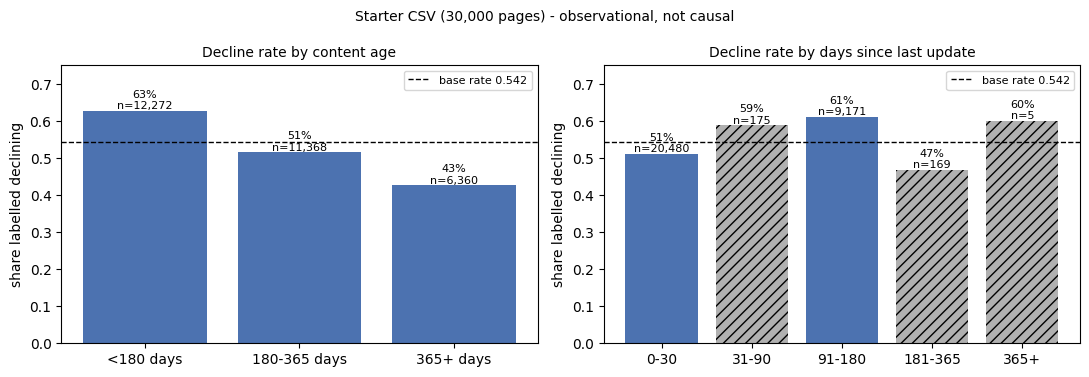

wrote work/figures/decay_refresh_insight.svg

What this changes about the actions:
  age reads clearly and the DIRECTION is against 'old content decays': 62.7% -> 51.5% -> 42.6%
  freshness does not read (non-monotonic; 3 of 5 buckets are under n=500) - reported as a negative result
  => the queue ranks on observed visibility at stake; age/freshness enter only as a review prompt, never as a refresh trigger


In [9]:
# ---- Decay / refresh insight from the committed starter CSV ----------------
STARTER = Path("data/raw/content_refresh_anonymized.csv")
s = pd.read_csv(STARTER)
print(f"content_age_days range: {s['content_age_days'].min():.0f} .. {s['content_age_days'].max():.0f} "
      "(no brand-new pages: survivorship caveat)")
s["down"] = (s["trend_direction"] == "down").astype(int)
starter_base = s["down"].mean()
s["age_bucket"] = pd.cut(s["content_age_days"], [0, 180, 365, 730],
                         labels=["<180 days", "180-365 days", "365+ days"])
s["fresh_bucket"] = pd.cut(s["days_since_last_update"], [-1, 30, 90, 180, 365, 10**6],
                           labels=["0-30", "31-90", "91-180", "181-365", "365+"])
SMALL_N = 500   # the floor for reading a bucket

age_tbl = s.groupby("age_bucket", observed=True)["down"].agg(decline_rate="mean", pages="count")
fresh_tbl = s.groupby("fresh_bucket", observed=True)["down"].agg(decline_rate="mean", pages="count")
age_tbl["readable"] = age_tbl["pages"] >= SMALL_N
fresh_tbl["readable"] = fresh_tbl["pages"] >= SMALL_N
print(f"starter CSV: {len(s):,} pages, decline base rate {starter_base:.3f} "
      f"(label = trend_direction == 'down')")
display(age_tbl.round(3))
display(fresh_tbl.round(3))

# The table must match the ML-10 receipts, else the paper's paragraph is stale.
decay = pb["decay_refresh_starter_csv"]
assert decay["pages"] == len(s)
for key, want in decay["by_age_bucket"].items():
    assert abs(float(age_tbl.loc[key, "decline_rate"]) - want["decline_rate"]) < 0.005, key
    assert int(age_tbl.loc[key, "pages"]) == want["pages"], key
print("decay tables match work/outputs/playbook_metrics.json within 0.005")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, tbl, title in ((axes[0], age_tbl, "Decline rate by content age"),
                       (axes[1], fresh_tbl, "Decline rate by days since last update")):
    colors = ["#4c72b0" if ok else "#b0b0b0" for ok in tbl["readable"]]
    bars = ax.bar(tbl.index.astype(str), tbl["decline_rate"], color=colors)
    for bar, row in zip(bars, tbl.itertuples()):
        ax.annotate(f"{row.decline_rate:.0%}\nn={row.pages:,}",
                    (bar.get_x() + bar.get_width() / 2, row.decline_rate),
                    ha="center", va="bottom", fontsize=8)
        if not row.readable:
            bar.set_hatch("///")
    ax.axhline(starter_base, color="black", ls="--", lw=1, label=f"base rate {starter_base:.3f}")
    ax.set_ylim(0, 0.75); ax.set_title(title, fontsize=10); ax.legend(fontsize=8)
    ax.set_ylabel("share labelled declining")
fig.suptitle("Starter CSV (30,000 pages) - observational, not causal", fontsize=10)
fig.tight_layout()
fig.savefig("work/figures/decay_refresh_insight.svg", bbox_inches="tight")
plt.show()
print("wrote work/figures/decay_refresh_insight.svg")

print("\nWhat this changes about the actions:")
print(f"  age reads clearly and the DIRECTION is against 'old content decays': "
      f"{age_tbl.loc['<180 days', 'decline_rate']:.1%} -> "
      f"{age_tbl.loc['180-365 days', 'decline_rate']:.1%} -> "
      f"{age_tbl.loc['365+ days', 'decline_rate']:.1%}")
print(f"  freshness does not read (non-monotonic; 3 of 5 buckets are under n={SMALL_N}) - "
      "reported as a negative result")
print("  => the queue ranks on observed visibility at stake; age/freshness enter only as a "
      "review prompt, never as a refresh trigger")

## 7. Artifacts the paper embeds

*Regenerate every figure the deployed page shows, then export the machine-checkable numbers.*

Four figures, all committed under `work/figures/`: the precision@K curves (the results figure), the queue's action/reason-code mix, cost vs value (capacity), and the decay/refresh context above. Then `work/outputs/capstone_metrics.json` collects every number the paper quotes, so a reader can diff the page against a fresh run. The queue CSV itself stays gitignored by design (CI blocks data CSVs) — ML-10 regenerates it.

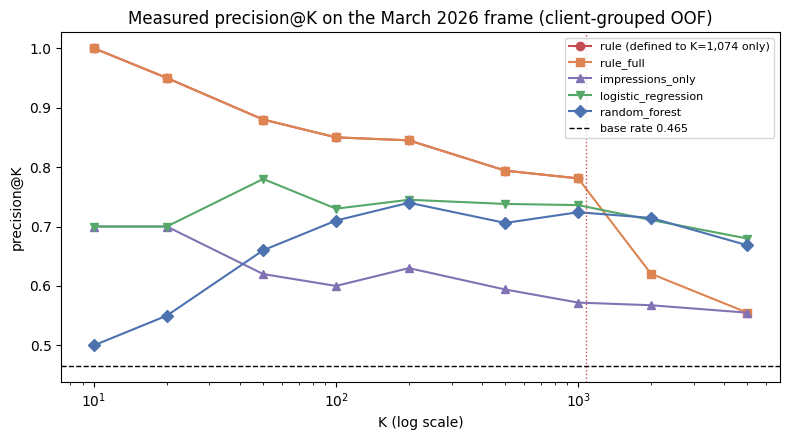

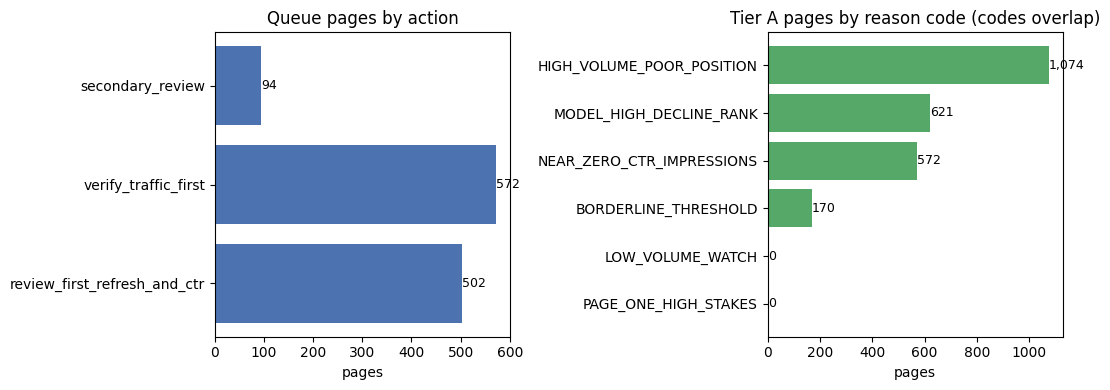

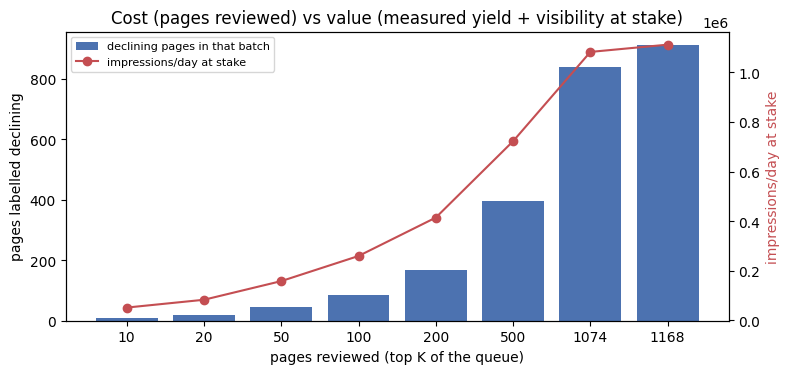

wrote work/figures/queue_yield_curve.svg, queue_action_mix.svg, capacity_vs_yield.svg


In [10]:
# ---- Figures for the paper -------------------------------------------------
Path("work/figures").mkdir(parents=True, exist_ok=True)

# 1) precision@K: the rule's top-of-queue lead vs the forest's whole-list lead
ks = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000]
fig, ax = plt.subplots(figsize=(8, 4.5))
style = {"rule": ("#c44e52", "o"), "rule_full": ("#dd8452", "s"),
         "impressions_only": ("#8172b3", "^"), "logistic_regression": ("#55a868", "v"),
         "random_forest": ("#4c72b0", "D")}
n_flag = int(flag.sum())
for name, (color, marker) in style.items():
    # `rule` scores 0 for every unflagged page, so past K = n_flag its "ranking" is tie order.
    kk = [k for k in ks if k <= n_flag] if name == "rule" else ks
    ax.plot(kk, [precision_at_k(y, scores[name], k) for k in kk], color=color, marker=marker,
            label=name if name != "rule" else f"rule (defined to K={n_flag:,} only)")
ax.axvline(n_flag, color="#c44e52", ls=":", lw=1)
ax.axhline(base_rate, color="black", ls="--", lw=1, label=f"base rate {base_rate:.3f}")
ax.set_xscale("log"); ax.set_xlabel("K (log scale)"); ax.set_ylabel("precision@K")
ax.set_title("Measured precision@K on the March 2026 frame (client-grouped OOF)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig("work/figures/queue_yield_curve.svg", bbox_inches="tight")
plt.show()

# 2) queue composition: actions + Tier A reason codes
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
order = ["review_first_refresh_and_ctr", "verify_traffic_first", "secondary_review"]
counts_a = queue["action"].value_counts().reindex([o for o in order if o in queue["action"].value_counts().index])
axes[0].barh(counts_a.index, counts_a.values, color="#4c72b0")
for i, v in enumerate(counts_a.values):
    axes[0].annotate(f"{v:,}", (v, i), va="center", fontsize=9)
axes[0].set_title("Queue pages by action"); axes[0].set_xlabel("pages")

rc_counts = df.loc[flag, CODE_COLS].sum().sort_values()
axes[1].barh([CODE_LABEL[c] for c in rc_counts.index], rc_counts.values, color="#55a868")
for i, v in enumerate(rc_counts.values):
    axes[1].annotate(f"{v:,}", (v, i), va="center", fontsize=9)
axes[1].set_title("Tier A pages by reason code (codes overlap)")
axes[1].set_xlabel("pages")
fig.tight_layout()
fig.savefig("work/figures/queue_action_mix.svg", bbox_inches="tight")
plt.show()

# 3) cost vs value: pages reviewed, declining pages found, visibility at stake
fig, ax = plt.subplots(figsize=(8, 4))
ks2 = [10, 20, 50, 100, 200, 500, len(tier_a), len(queue)]
sub_counts = [int(queue.head(k)["is_declining_label"].sum()) for k in ks2]
sub_impr = [int(queue.head(k)["gsc_impressions_avg"].sum()) for k in ks2]
bars = ax.bar([str(k) for k in ks2], sub_counts, color="#4c72b0",
              label="declining pages in that batch")
ax.set_xlabel("pages reviewed (top K of the queue)"); ax.set_ylabel("pages labelled declining")
ax2 = ax.twinx()
line, = ax2.plot([str(k) for k in ks2], sub_impr, color="#c44e52", marker="o",
                 label="impressions/day at stake")
ax2.set_ylabel("impressions/day at stake", color="#c44e52")
ax.set_title("Cost (pages reviewed) vs value (measured yield + visibility at stake)")
ax.legend([bars, line], [bars.get_label(), line.get_label()], fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig("work/figures/capacity_vs_yield.svg", bbox_inches="tight")
plt.show()
print("wrote work/figures/queue_yield_curve.svg, queue_action_mix.svg, capacity_vs_yield.svg")

In [11]:
# ---- Export the paper's numbers + verify every artifact --------------------
OUT, FIG = Path("work/outputs"), Path("work/figures")
OUT.mkdir(parents=True, exist_ok=True)

def _jsonable(o):
    if isinstance(o, (np.integer,)): return int(o)
    if isinstance(o, (np.floating,)): return float(o)
    if isinstance(o, (np.bool_,)): return bool(o)
    return str(o)

capacity_rows = capacity.to_dict(orient="records")
capstone_metrics = {
    "assignment": "ML-11 capstone (paper mirrors this notebook)",
    "frame": {"window": "2026-03-01..2026-03-31", "features": BASE_FEATURES,
              "label": "impressions days 16-31 < days 1-15", "pages": len(df),
              "clients": int(df["client_hash_id"].nunique()),
              "base_rate": round(base_rate, 4), "flagged_by_rule": int(flag.sum()),
              "split": f"client-grouped {N_FOLDS}-fold OOF", "random_state": RANDOM_STATE,
              "rows_before_filter": n_before,
              "excluded": {"position_nan": n_pos_nan, "position_zero": n_pos_zero,
                           "undefined_label": n_lab_nan_extra}},
    "receipts": {m: {k: round(v, 4) for k, v in b.items()} for m, b in pooled.items()},
    "reproduction": {"published_numbers_checked": len(receipts),
                     "match": int((receipts["check"] == "MATCH").sum()),
                     "max_abs_diff": round(worst, 4), "tolerance": 0.005,
                     "also_checked": "work/outputs/playbook_metrics.json (all receipts)"},
    "queue": {"total": len(queue), "tier_a": len(tier_a), "tier_b": len(tier_b),
              "declining_rate": round(queue["is_declining_label"].mean(), 4),
              "action_mix": queue["action"].value_counts().to_dict(),
              "confidence_mix": queue["confidence"].value_counts().to_dict(),
              "archetype_mix": df["archetype"].value_counts().to_dict(),
              "top50_near_zero_ctr": int(queue.head(50)["rc_near_zero_ctr"].sum()),
              "top50_clients": int(queue.head(50)["client_hash_id"].nunique()),
              "tier_a_visibility_share": round(
                  float(tier_a["gsc_impressions_avg"].sum() / TOTAL_IMPR), 4)},
    "capacity": capacity_rows,
    "limitations": {"near_zero_ctr_in_tier_a": near_zero_flagged,
                    "largest_client_share_of_flagged": round(float(largest_client_share), 4),
                    "triggers_firing": firing},
    "figures": ["queue_yield_curve.svg", "queue_action_mix.svg",
                "capacity_vs_yield.svg", "decay_refresh_insight.svg"],
    "note": "queue CSV stays gitignored (CI blocks data CSVs) - regenerate via ML-10",
}
metrics_path = OUT / "capstone_metrics.json"
metrics_path.write_text(json.dumps(capstone_metrics, indent=2, default=_jsonable),
                        encoding="utf-8")

print("Artifacts the paper embeds:")
for name in capstone_metrics["figures"]:
    p = FIG / name
    print(f"  {p}  ({p.stat().st_size:,} bytes)" if p.exists() else f"  MISSING {p}")
    assert p.exists(), f"figure missing: {name}"
print(f"  {metrics_path}  ({metrics_path.stat().st_size:,} bytes)")
print(f"  reproduction: {capstone_metrics['reproduction']['match']}/"
      f"{capstone_metrics['reproduction']['published_numbers_checked']} published numbers, "
      f"max gap {capstone_metrics['reproduction']['max_abs_diff']}")

print("\nGit status of each artifact (regeneration note for the paper):")
for target, want_ignored in ((metrics_path, False), (FIG / "queue_yield_curve.svg", False),
                             (CACHE, True)):
    ignored = subprocess.run(["git", "check-ignore", "-q", str(target)],
                             capture_output=True).returncode == 0
    print(f"  {'gitignored' if ignored else 'committable'} | {target}: "
          f"{'OK' if ignored == want_ignored else 'CHECK'}")

# ---- Banned-phrasing scan over this notebook's own markdown ----------------
import re
BANNED = ["proves", "proven", "causes", "caused", "will increase", "will improve",
          "will recover", "guarantee", "definitive", "undeniable", "no doubt",
          "predicts google", "algorithm rewards", "surely", "obviously"]
this_nb = json.loads(Path("work/notebooks/capstone.ipynb").read_text(encoding="utf-8"))
hits = []
for idx, cell in enumerate(this_nb["cells"]):
    if cell["cell_type"] != "markdown":
        continue   # the banned list lives in a code cell, so it cannot trip the scan
    for line in "".join(cell["source"]).splitlines():
        for phrase in BANNED:
            if re.search(r"\b" + re.escape(phrase) + r"\b", line.lower()):
                hits.append((idx, phrase, line.strip()[:160]))
print(f"\nBanned-phrasing scan over this notebook's markdown ({len(BANNED)} phrases) -> "
      f"{len(hits)} hit(s):")
for idx, phrase, line in hits:
    print(f"  cell {idx}: [{phrase}] {line}")
if not hits:
    print("  none - every claim sentence stays inside the ladder "
          "(observed / measured / directional / decision-support).")

Artifacts the paper embeds:
  work\figures\queue_yield_curve.svg  (53,879 bytes)
  work\figures\queue_action_mix.svg  (56,018 bytes)
  work\figures\capacity_vs_yield.svg  (45,850 bytes)
  work\figures\decay_refresh_insight.svg  (57,075 bytes)
  work\outputs\capstone_metrics.json  (4,441 bytes)
  reproduction: 25/25 published numbers, max gap 0.0

Git status of each artifact (regeneration note for the paper):


  committable | work\outputs\capstone_metrics.json: OK


  committable | work\figures\queue_yield_curve.svg: OK


  gitignored | work\outputs\feature_frame_march_audit.csv: OK

Banned-phrasing scan over this notebook's markdown (15 phrases) -> 0 hit(s):
  none - every claim sentence stays inside the ladder (observed / measured / directional / decision-support).


## Self-check

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] Question and decision written down before training; the metric named (and tested) before any model
- [x] Data section states release, tables, window, exclusions with counts, and what was deliberately not used
- [x] Methodology states assumptions, the three features, the observed label, the transparent baseline, the grouped split, and the leakage checks — all asserted in code
- [x] Results: model vs baseline on the same split, base rate beside every table, 25/25 published numbers reproduced within 0.005 and cross-checked against `work/outputs/playbook_metrics.json`
- [x] Limitations: seven named limits, live values re-measured and reconciled with the receipts file, three triggers shown as FIRING rather than hidden
- [x] Ranked recommendations: tiered queue with reason codes, actions, confidence and per-row `wrong_if`, matched against the receipts; capacity table; decay insight kept as context with its different-dataset caveats
- [x] Artifacts: four figures regenerated, `work/outputs/capstone_metrics.json` written, gitignore status verified (queue CSV stays out of git)
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere (pseudonymous IDs, aggregates, charts only)
- [x] Claims use careful words: observed, measured, directional, decision-support — with the banned-phrasing scan printed above
- [x] Committed to my repo under `work/notebooks/` — the deployed paper cites this notebook in its Reproducibility section